In [118]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Time series specific imports
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# Machine learning models
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Set visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

### 1. Data Loading and Preparation ###

In [119]:
# Load the datasets
df_clean = pd.read_csv('dc_housing_modeling_features_clean.csv', parse_dates=['Date'], index_col='Date')

# Display dataset information
print(f"Clean dataset shape: {df_clean.shape}")
print(f"Imputed dataset shape: {df_partial.shape}")
print(f"Clean dataset time range: {df_clean.index.min()} to {df_clean.index.max()}")
print(f"Imputed dataset time range: {df_partial.index.min()} to {df_partial.index.max()}")

# Display sample from each dataset
print("\nClean dataset sample:")
print(df_clean.head(3))

print("\nImputed dataset sample:")
print(df_partial.head(3))

# Prepare data for modeling
X = df_clean.drop('ZHVI_pct_change', axis=1)
y = df_clean['ZHVI_pct_change']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("\nData preparation complete:")
print(f"Features shape after scaling: {X_scaled_df.shape}")

Clean dataset shape: (89, 22)
Imputed dataset shape: (100, 35)
Clean dataset time range: 2001-04-01 00:00:00 to 2023-04-01 00:00:00
Imputed dataset time range: 2000-01-01 00:00:00 to 2024-10-01 00:00:00

Clean dataset sample:
            ZHVI_pct_change  Unemployment_Rate  Median_Household_Income    CPI  GDP_Growth  Poverty_Rate_lag5  CPI_pct_change  Unemployment_Rate_pct_change  Median_Household_Income_pct_change  Population_pct_change  Poverty_Rate_pct_change  Income_yoy_pct  Interest_Rate_diff1  Mortgage_Rate_diff1  real_mortgage_rate  Income_CPI_interaction  hot_market  rising_rates  accelerating_prices  accelerating_inflation  recession_period  pandemic_period
Date                                                                                                                                                                                                                                                                                                                                  

### 2. Model Evaluation Functions ###

In [120]:
def evaluate_model_with_tscv(model, X, y, cv, name="Model"):
    """Evaluate model with time series cross-validation"""
    cv_scores_rmse = []
    cv_scores_mae = []
    cv_scores_r2 = []
    
    # For plotting actual vs predicted
    all_y_test = []
    all_y_pred = []
    all_test_indices = []
    
    for train_idx, test_idx in cv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Store test results for plotting
        all_y_test.extend(y_test)
        all_y_pred.extend(y_pred)
        all_test_indices.extend(test_idx)
        
        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        cv_scores_rmse.append(rmse)
        cv_scores_mae.append(mae)
        cv_scores_r2.append(r2)
    
    # Print average metrics
    print(f"{name} Cross-validation Results:")
    print(f"RMSE: {np.mean(cv_scores_rmse):.2f} (±{np.std(cv_scores_rmse):.2f})")
    print(f"MAE: {np.mean(cv_scores_mae):.2f} (±{np.std(cv_scores_mae):.2f})")
    print(f"R²: {np.mean(cv_scores_r2):.3f} (±{np.std(cv_scores_r2):.3f})")
    
    # Create a DataFrame with test results for plotting
    results_df = pd.DataFrame({
        'Index': X.iloc[all_test_indices].index,
        'Actual': all_y_test,
        'Predicted': all_y_pred
    }).sort_values('Index')
    
    return results_df, np.mean(cv_scores_rmse), np.mean(cv_scores_r2)

def generate_cv_predictions(model, X, y, cv=5):
    """Generate predictions using time series cross-validation"""
    tscv = TimeSeriesSplit(n_splits=cv)
    
    # For storing predictions
    all_predictions = []
    all_test_indices = []
    
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Store predictions and indices
        for i, idx in enumerate(test_idx):
            all_predictions.append(y_pred[i])
            all_test_indices.append(idx)
    
    # Create a DataFrame with results
    results_df = pd.DataFrame({
        'Index': X.iloc[all_test_indices].index,
        'Actual': y.iloc[all_test_indices].values,
        'Predicted': all_predictions
    }).sort_values('Index')
    
    return results_df

def plot_ts_cv_splits(X, n_splits):
    """Visualize time series cross-validation splits"""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    plt.figure(figsize=(15, n_splits*1.5))
    plt.suptitle(f'TimeSeriesSplit with {n_splits} splits', fontsize=15)
    
    for i, (train_index, test_index) in enumerate(tscv.split(X)):
        # Plot the training set
        train_start_idx = np.min(train_index)
        train_end_idx = np.max(train_index)
        
        # Plot the test set
        test_start_idx = np.min(test_index)
        test_end_idx = np.max(test_index)
        
        # Create the plot
        plt.subplot(n_splits, 1, i+1)
        plt.fill_between([train_start_idx, train_end_idx], 0, 1, color='lightblue', alpha=0.5, label='Train')
        plt.fill_between([test_start_idx, test_end_idx], 0, 1, color='coral', alpha=0.5, label='Test')
        
        # Format
        if i == 0:
            plt.legend(loc='center right')
        plt.yticks([])
        plt.title(f'Split {i+1}', fontsize=10)
        
        # Add text with train/test sizes
        train_size = len(train_index)
        test_size = len(test_index)
        plt.text(train_start_idx + (train_end_idx - train_start_idx)/2, 0.5, f'Train: {train_size}', 
                ha='center', va='center', fontsize=9)
        plt.text(test_start_idx + (test_end_idx - test_start_idx)/2, 0.5, f'Test: {test_size}', 
                ha='center', va='center', fontsize=9)
        
        # Add date ranges
        date_start = X.index[train_start_idx].strftime('%Y-%m')
        date_mid = X.index[train_end_idx].strftime('%Y-%m')
        date_end = X.index[test_end_idx].strftime('%Y-%m')
        
        plt.xlabel(f'Index (Dates: {date_start} to {date_mid} | Test: to {date_end})', fontsize=8)
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

### 3. Baseline Model Evaluation ###

Base Ridge (alpha=1.0) Cross-validation Results:
RMSE: 2.82 (±1.86)
MAE: 2.50 (±1.80)
R²: -7.076 (±6.443)


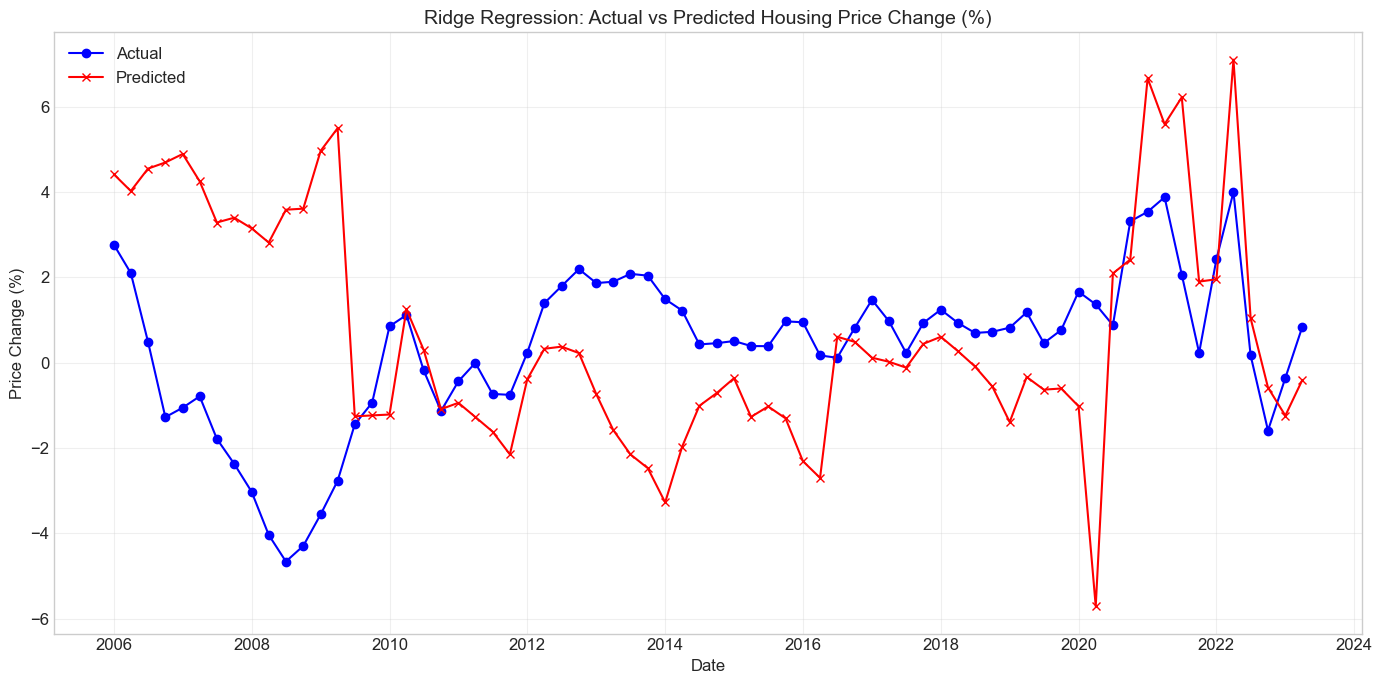

In [121]:
# Setup time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)  # Start with 5

# Evaluate base Ridge model with default alpha
base_ridge = Ridge(alpha=1.0)
results_base_ridge, base_rmse, base_r2 = evaluate_model_with_tscv(
    base_ridge, X_scaled_df, y, tscv, "Base Ridge (alpha=1.0)"
)

# Plot actual vs predicted values for baseline model
plt.figure(figsize=(14, 7))
plt.plot(results_base_ridge['Index'], results_base_ridge['Actual'], marker='o', label='Actual', color='blue')
plt.plot(results_base_ridge['Index'], results_base_ridge['Predicted'], marker='x', label='Predicted', color='red')
plt.title('Ridge Regression: Actual vs Predicted Housing Price Change (%)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price Change (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Hyperparameter Tuning ###


Testing with 2 folds...
Folds: 2, Best alpha: 73.0, Best RMSE: 1.4364, Avg R²: -0.2025

Testing with 3 folds...
Folds: 3, Best alpha: 10.0, Best RMSE: 2.8150, Avg R²: -5.1624

Testing with 4 folds...
Folds: 4, Best alpha: 100.0, Best RMSE: 3.0664, Avg R²: -2.6135

Testing with 5 folds...
Folds: 5, Best alpha: 100.0, Best RMSE: 2.9442, Avg R²: -1.9139

Testing with 6 folds...
Folds: 6, Best alpha: 60.0, Best RMSE: 2.6241, Avg R²: -4.3882

Testing with 7 folds...
Folds: 7, Best alpha: 10.0, Best RMSE: 2.4847, Avg R²: -11.6900

===== OPTIMAL CONFIGURATION =====
Optimal number of folds: 2
Optimal alpha: 73.0
RMSE with optimal configuration: 1.4364
R² with optimal configuration: -0.2025


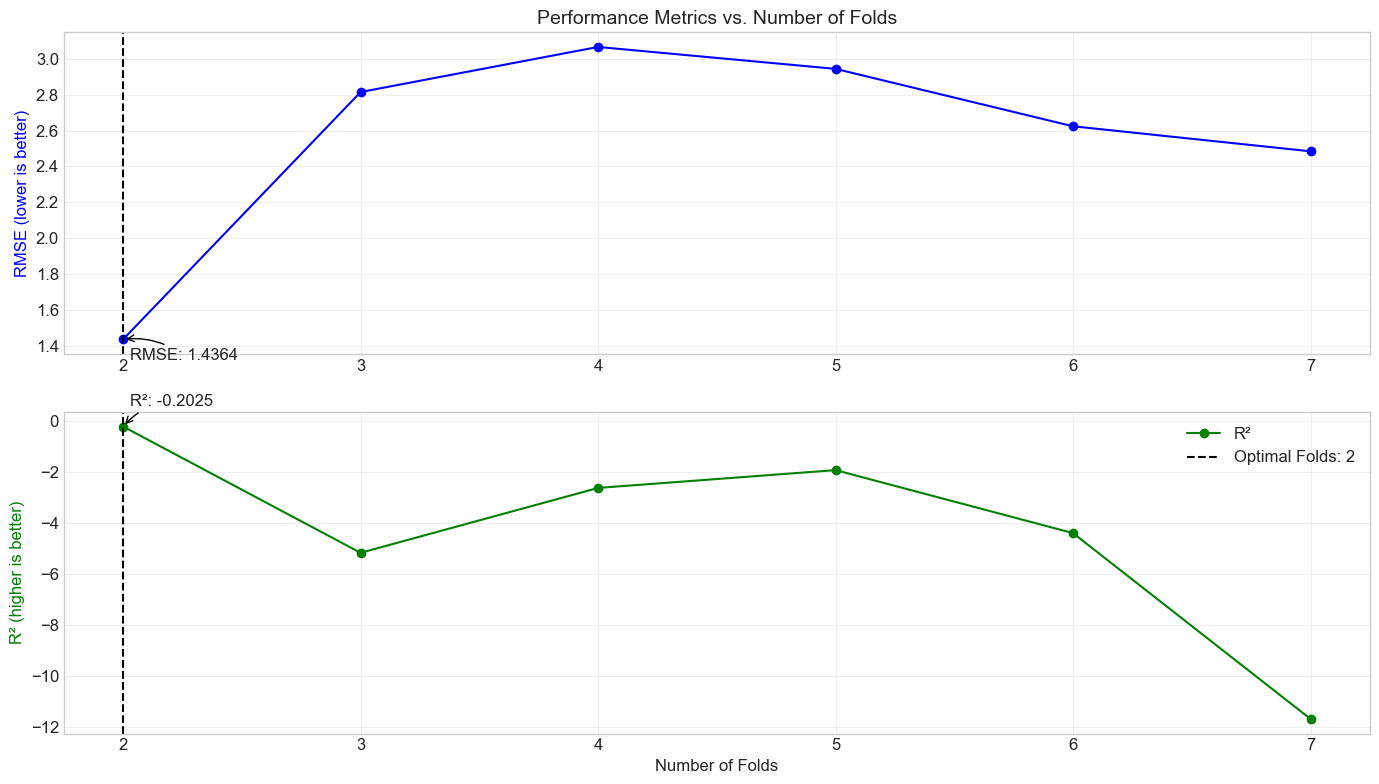

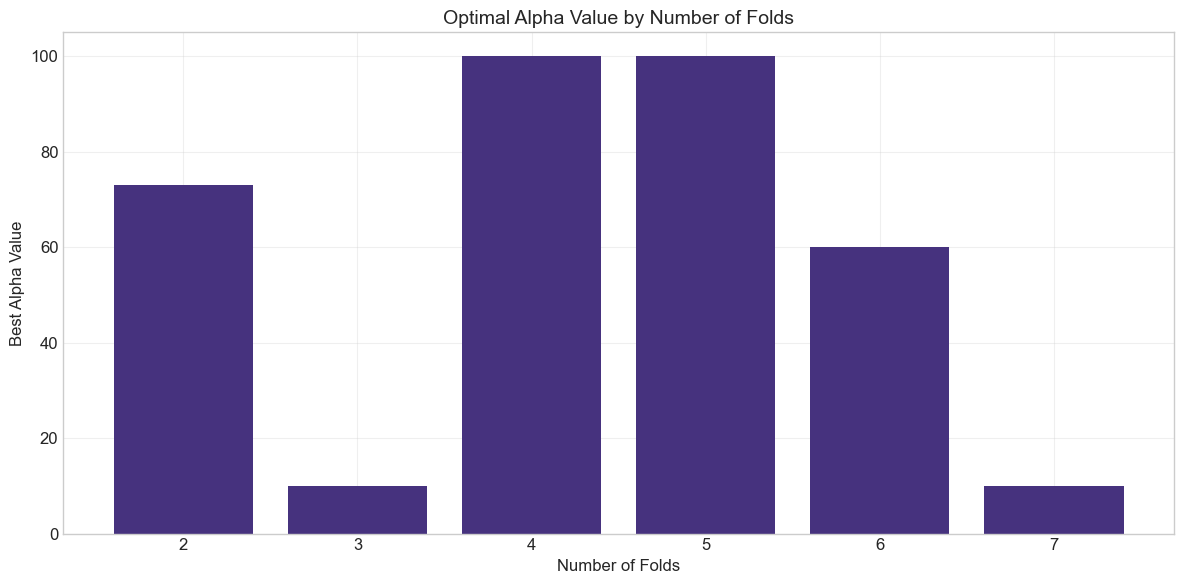


Detailed results for all fold counts:
Optimal index: 0
Row at optimal index:
 n_folds       2.00
best_alpha   73.00
best_rmse     1.44
avg_r2       -0.20
Name: 0, dtype: float64
   n_folds  best_alpha  best_rmse  avg_r2
0        2       73.00       1.44   -0.20
1        3       10.00       2.82   -5.16
2        4      100.00       3.07   -2.61
3        5      100.00       2.94   -1.91
4        6       60.00       2.62   -4.39
5        7       10.00       2.48  -11.69


In [122]:
# Step 6: Hyperparameter tuning with grid search for both alpha and number of folds
# Define parameter grid for Ridge regression
param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 60.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 80.0, 90.0, 100.0, 200.0, 300.0, 400.0, 500.0, 600.0, 700.0, 800.0, 900.0, 1000.0]
}

# Test different numbers of folds to find the optimal
fold_counts = [2, 3, 4, 5, 6, 7]
fold_results = []

for n_folds in fold_counts:
    print(f"\nTesting with {n_folds} folds...")
    
    # Create time series split for this fold count
    tscv_grid = TimeSeriesSplit(n_splits=n_folds)
    
    # Setup grid search
    grid_search = GridSearchCV(
        Ridge(), 
        param_grid, 
        cv=tscv_grid,
        scoring='neg_mean_squared_error',
        verbose=0,  # Set to 0 to reduce output clutter
        return_train_score=True
    )
    
    # Fit grid search
    grid_search.fit(X_scaled, y)
    
    # Get best alpha and score for this fold count
    best_alpha = grid_search.best_params_['alpha']
    best_score = grid_search.best_score_
    best_rmse = np.sqrt(-best_score)
    
    # Calculate R² for this configuration
    # We'll need to manually compute average R² across folds
    r2_scores = []
    for train_idx, test_idx in tscv_grid.split(X_scaled):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model = Ridge(alpha=best_alpha)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        r2_scores.append(r2)
    
    avg_r2 = np.mean(r2_scores)
    
    # Store results
    fold_results.append({
        'n_folds': n_folds,
        'best_alpha': best_alpha,
        'best_rmse': best_rmse,
        'avg_r2': avg_r2
    })
    
    print(f"Folds: {n_folds}, Best alpha: {best_alpha}, Best RMSE: {best_rmse:.4f}, Avg R²: {avg_r2:.4f}")

# Convert results to DataFrame
fold_results_df = pd.DataFrame(fold_results)

# Find the optimal combination
optimal_idx = fold_results_df['avg_r2'].idxmax()  # Use R² to find optimal (higher is better)
optimal_folds = fold_results_df.loc[optimal_idx, 'n_folds']
optimal_alpha = fold_results_df.loc[optimal_idx, 'best_alpha']

print("\n===== OPTIMAL CONFIGURATION =====")
print(f"Optimal number of folds: {optimal_folds}")
print(f"Optimal alpha: {optimal_alpha}")
print(f"RMSE with optimal configuration: {fold_results_df.loc[optimal_idx, 'best_rmse']:.4f}")
print(f"R² with optimal configuration: {fold_results_df.loc[optimal_idx, 'avg_r2']:.4f}")

# Plot the results to visualize the trade-offs
plt.figure(figsize=(14, 8))

# Create a subplot for RMSE
ax1 = plt.subplot(2, 1, 1)
ax1.plot(fold_results_df['n_folds'], fold_results_df['best_rmse'], 'o-', color='blue', label='RMSE')
ax1.set_ylabel('RMSE (lower is better)', color='blue')
ax1.axvline(x=optimal_folds, color='black', linestyle='--')
ax1.grid(True, alpha=0.3)
ax1.set_title('Performance Metrics vs. Number of Folds', fontsize=14)

# Create a subplot for R²
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
ax2.plot(fold_results_df['n_folds'], fold_results_df['avg_r2'], 'o-', color='green', label='R²')
ax2.set_ylabel('R² (higher is better)', color='green')
ax2.axvline(x=optimal_folds, color='black', linestyle='--', label=f'Optimal Folds: {optimal_folds}')
ax2.set_xlabel('Number of Folds')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Annotate optimal points
ax1.annotate(f'RMSE: {fold_results_df.loc[optimal_idx, "best_rmse"]:.4f}', 
            xy=(optimal_folds, fold_results_df.loc[optimal_idx, 'best_rmse']),
            xytext=(5, -15), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2'))

ax2.annotate(f'R²: {fold_results_df.loc[optimal_idx, "avg_r2"]:.4f}', 
            xy=(optimal_folds, fold_results_df.loc[optimal_idx, 'avg_r2']),
            xytext=(5, 15), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2'))

plt.tight_layout()
plt.show()

# Also show the alpha values selected for each fold count
plt.figure(figsize=(12, 6))
plt.bar(fold_results_df['n_folds'].astype(str), fold_results_df['best_alpha'])
plt.title('Optimal Alpha Value by Number of Folds', fontsize=14)
plt.xlabel('Number of Folds')
plt.ylabel('Best Alpha Value')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Create a table for detailed results
print("\nDetailed results for all fold counts:")
print("Optimal index:", optimal_idx)
print("Row at optimal index:\n", fold_results_df.loc[optimal_idx])
print(fold_results_df[['n_folds', 'best_alpha', 'best_rmse', 'avg_r2']])

### 5. Time Series Cross-Validation Visualization ###

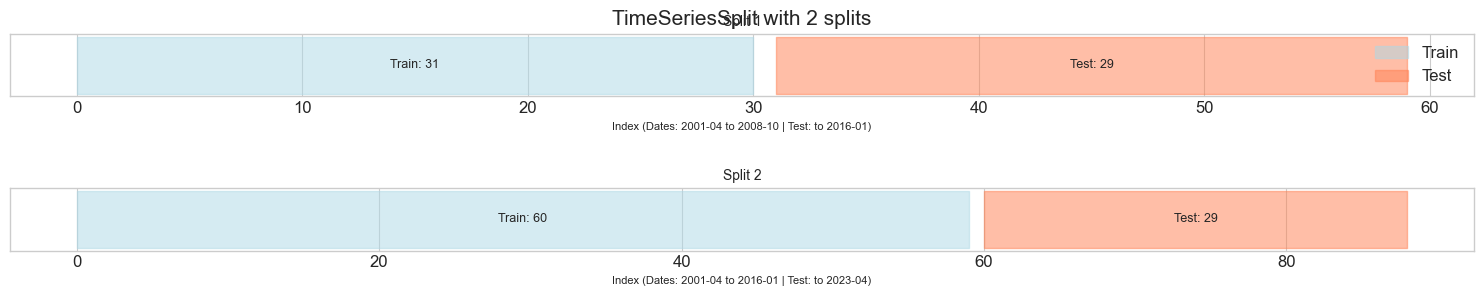

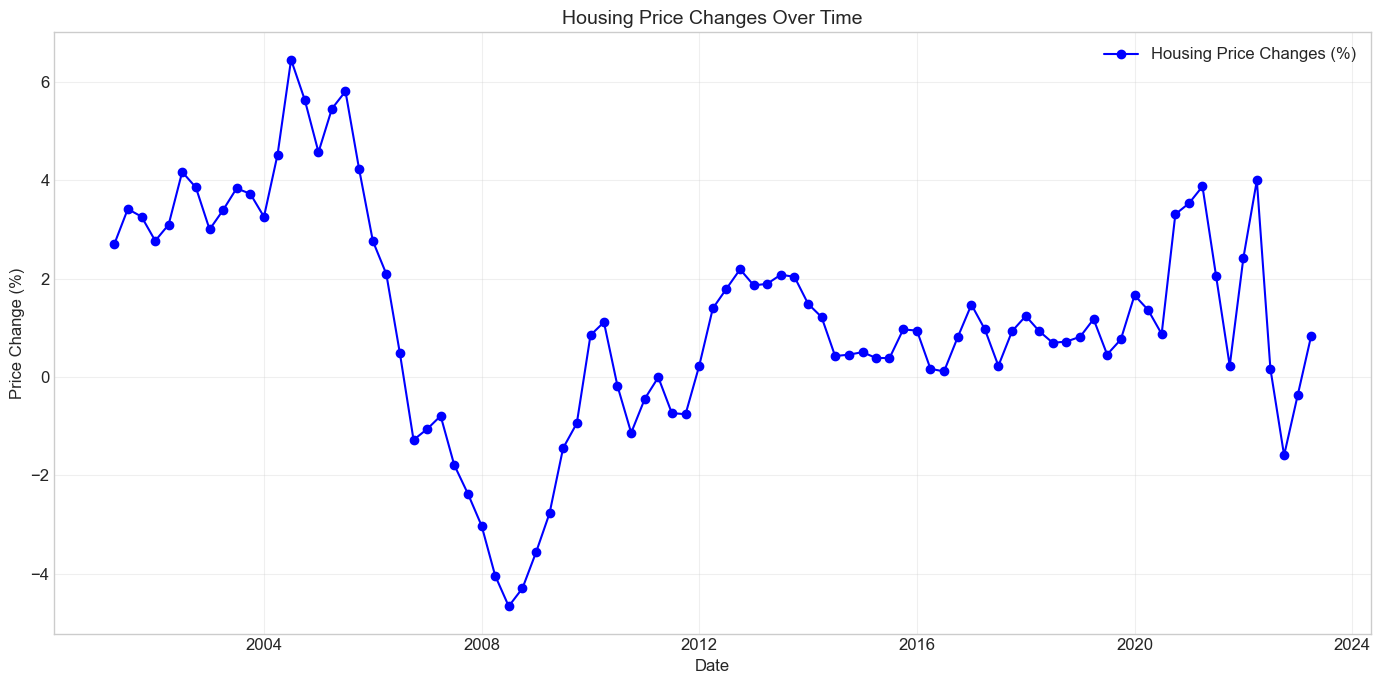

In [123]:
# Visualize how time series cross-validation works
plot_ts_cv_splits(X_scaled_df, n_splits=2)

# Visualize the target variable over time
plt.figure(figsize=(14, 7))
plt.plot(y.index, y, 'o-', label='Housing Price Changes (%)', color='blue')
plt.title('Housing Price Changes Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price Change (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 6. Final Model With Optimal Alpha

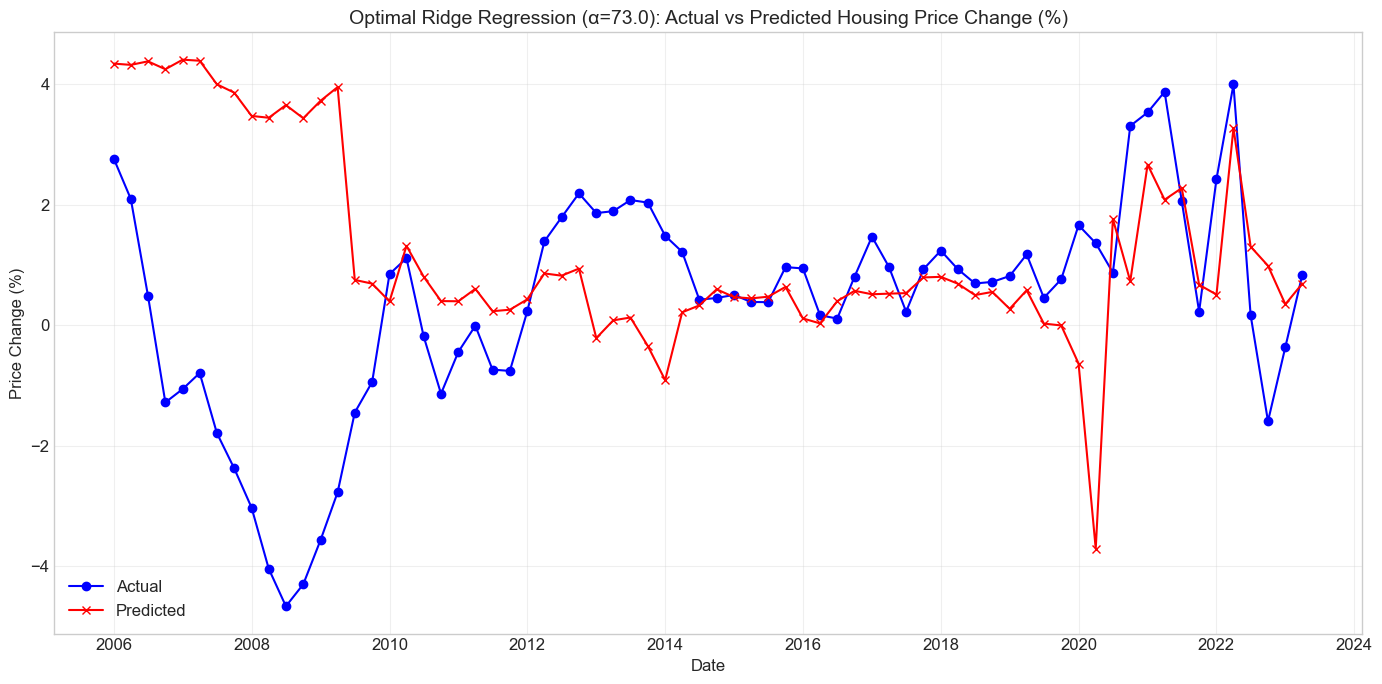

Optimal Ridge Model (α=73.0) Cross-Validation Performance:
RMSE: 2.9470
MAE: 1.9113
R²: -1.7054

Actual values range: -4.66 to 4.00
Predicted values range: -3.71 to 4.41


In [124]:
# Train the final model with optimal alpha
final_ridge = Ridge(alpha=optimal_alpha)
final_ridge.fit(X_scaled, y)

# Generate predictions with optimal alpha
results_optimal_ridge = generate_cv_predictions(final_ridge, X_scaled_df, y, cv=5)

# Plot actual vs predicted values for optimal model
plt.figure(figsize=(14, 7))
plt.plot(results_optimal_ridge['Index'], results_optimal_ridge['Actual'], marker='o', label='Actual', color='blue')
plt.plot(results_optimal_ridge['Index'], results_optimal_ridge['Predicted'], marker='x', label='Predicted', color='red')
plt.title(f'Optimal Ridge Regression (α={optimal_alpha}): Actual vs Predicted Housing Price Change (%)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price Change (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate cross-validation performance metrics
cv_rmse = np.sqrt(mean_squared_error(results_optimal_ridge['Actual'], results_optimal_ridge['Predicted']))
cv_r2 = r2_score(results_optimal_ridge['Actual'], results_optimal_ridge['Predicted'])
cv_mae = mean_absolute_error(results_optimal_ridge['Actual'], results_optimal_ridge['Predicted'])

print(f"Optimal Ridge Model (α={optimal_alpha}) Cross-Validation Performance:")
print(f"RMSE: {cv_rmse:.4f}")
print(f"MAE: {cv_mae:.4f}")
print(f"R²: {cv_r2:.4f}")

# Check range of predictions vs actuals
print(f"\nActual values range: {results_optimal_ridge['Actual'].min():.2f} to {results_optimal_ridge['Actual'].max():.2f}")
print(f"Predicted values range: {results_optimal_ridge['Predicted'].min():.2f} to {results_optimal_ridge['Predicted'].max():.2f}")

### 7. In-Sample Performance


In-sample performance (α=73.0):
RMSE: 1.4762
MAE: 1.1374
R²: 0.5685
Note: In-sample metrics typically look better than cross-validation metrics


c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


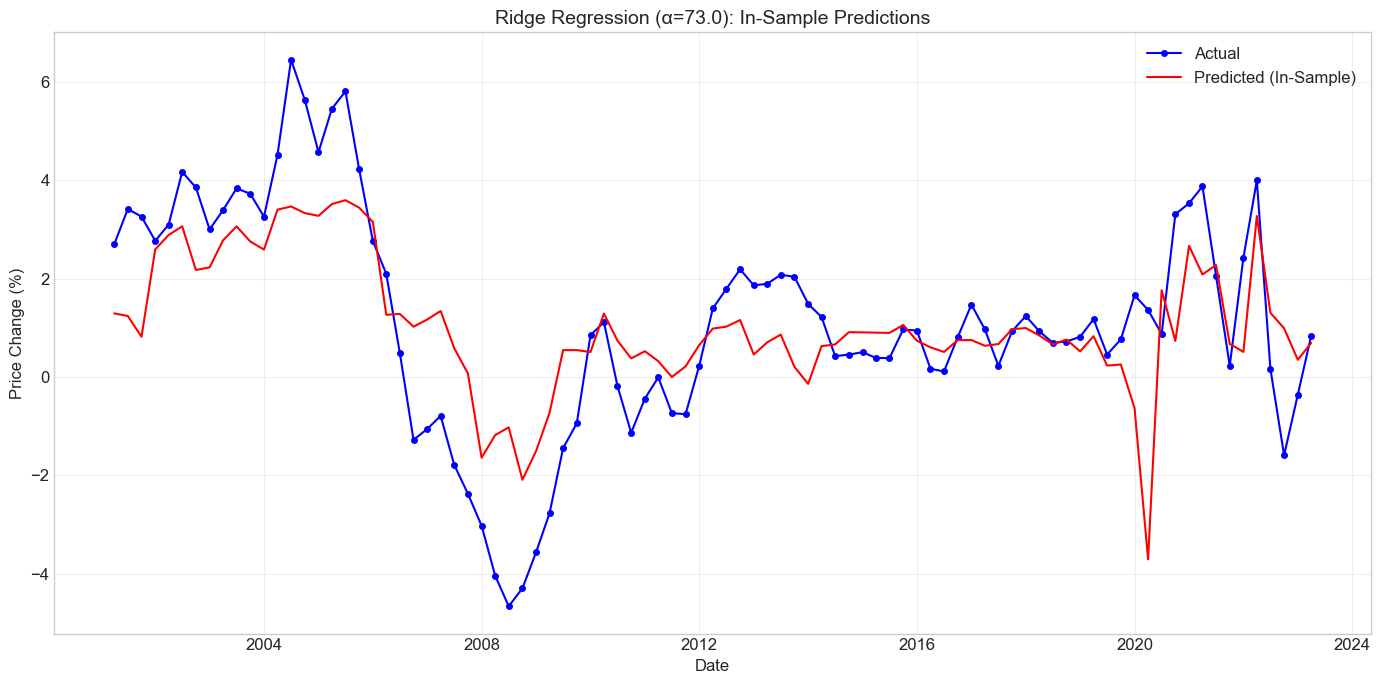

In [125]:
# Calculate in-sample performance (fitting and testing on same data)
in_sample_preds = final_ridge.predict(X_scaled)

in_sample_rmse = np.sqrt(mean_squared_error(y, in_sample_preds))
in_sample_r2 = r2_score(y, in_sample_preds)
in_sample_mae = mean_absolute_error(y, in_sample_preds)

print(f"\nIn-sample performance (α={optimal_alpha}):")
print(f"RMSE: {in_sample_rmse:.4f}")
print(f"MAE: {in_sample_mae:.4f}")
print(f"R²: {in_sample_r2:.4f}")
print("Note: In-sample metrics typically look better than cross-validation metrics")

# Plot in-sample predictions
plt.figure(figsize=(14, 7))
plt.plot(y.index, y, marker='o', markersize=4, label='Actual', color='blue')
plt.plot(y.index, in_sample_preds, marker='', linestyle='-', label='Predicted (In-Sample)', color='red')
plt.title(f'Ridge Regression (α={optimal_alpha}): In-Sample Predictions', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price Change (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 8. Feature Importance Analysis

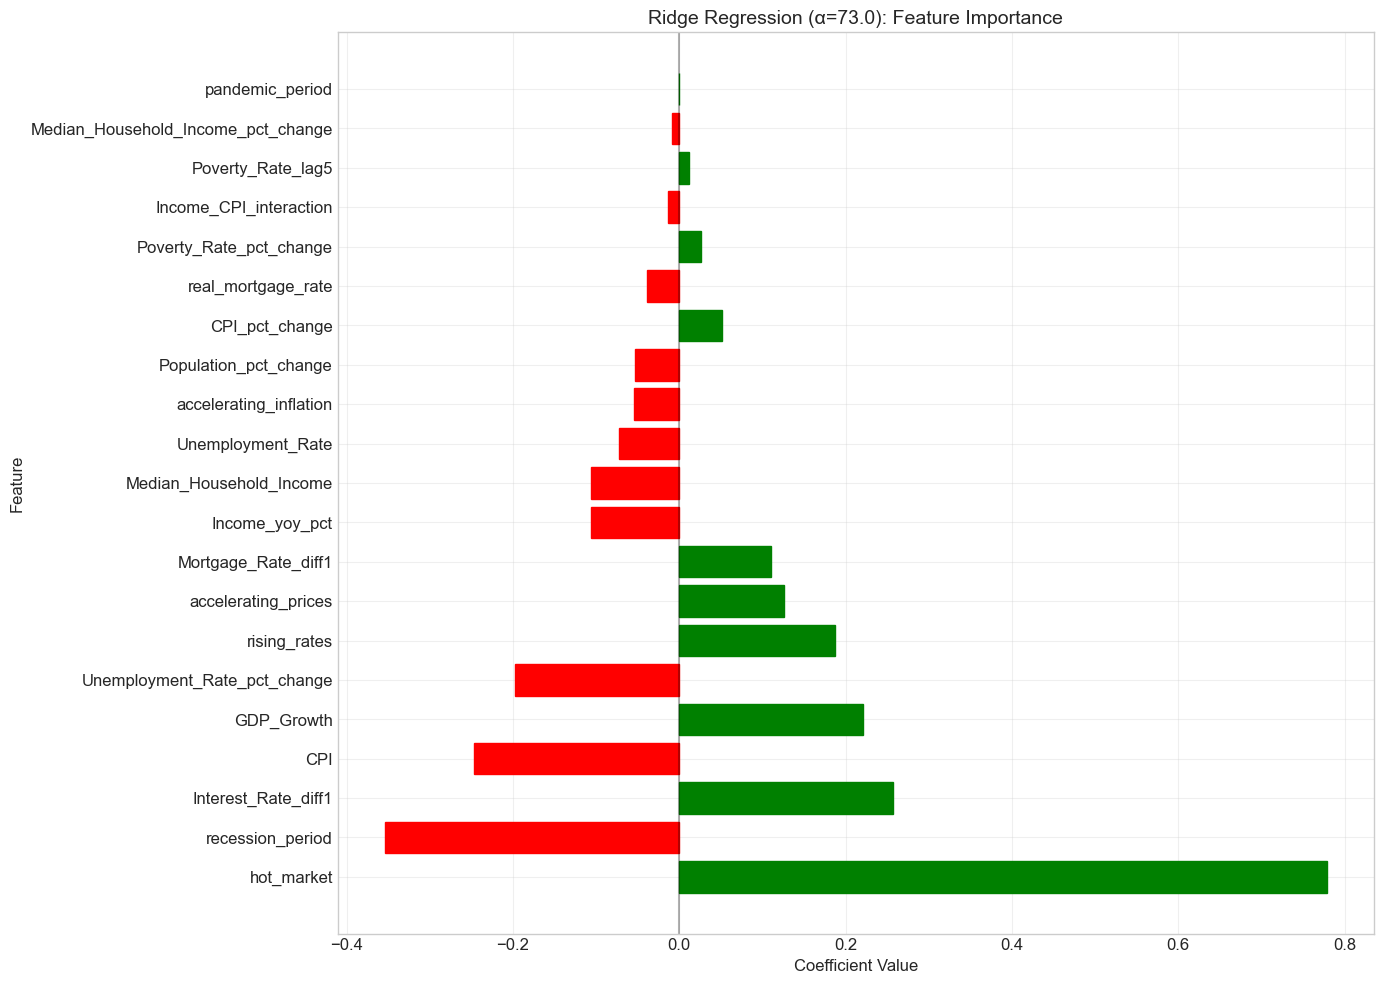

In [126]:
# Analyze feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': final_ridge.coef_,
    'Abs_Coefficient': np.abs(final_ridge.coef_)
})

# Sort by absolute coefficient value
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

# Plot feature importance
plt.figure(figsize=(14, 10))
bars = plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])

# Color the bars based on the sign of the coefficient
for i, bar in enumerate(bars):
    if feature_importance.iloc[i]['Coefficient'] < 0:
        bar.set_color('red')
    else:
        bar.set_color('green')

plt.title(f'Ridge Regression (α={optimal_alpha}): Feature Importance', fontsize=14)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9. Residual Analysis

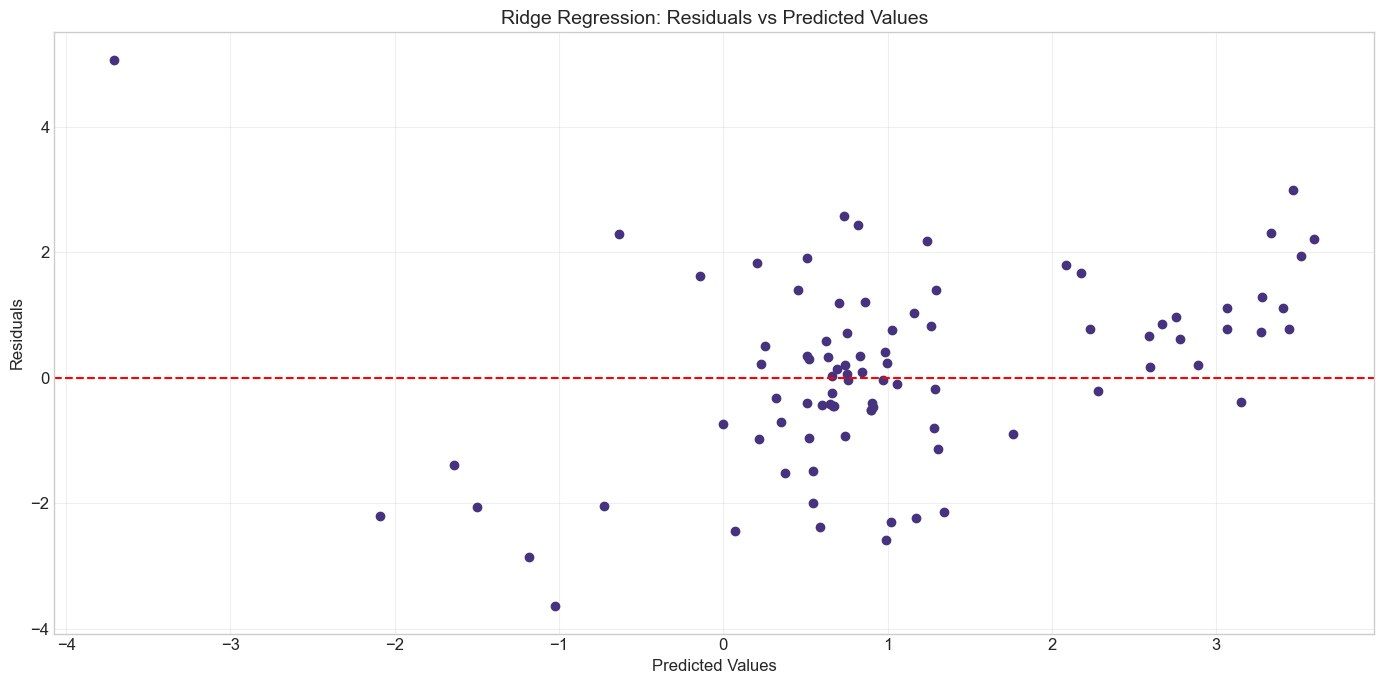

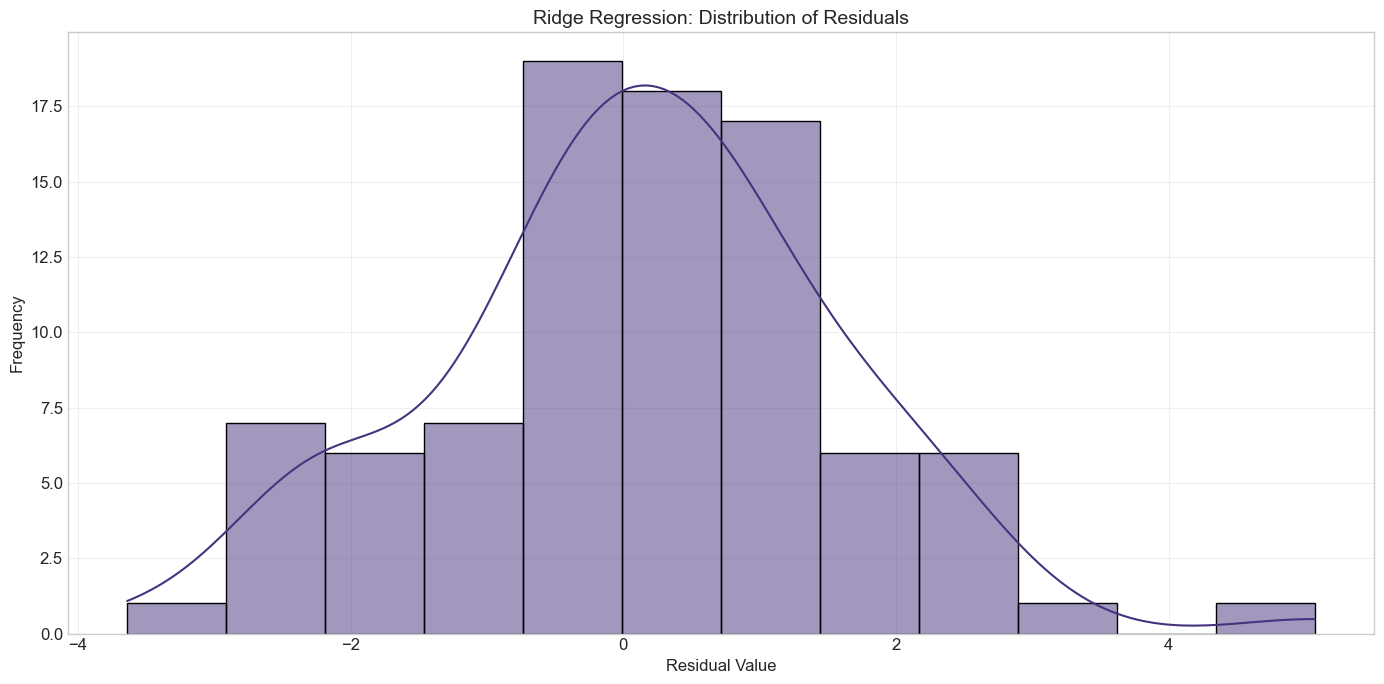

<Figure size 1400x700 with 0 Axes>

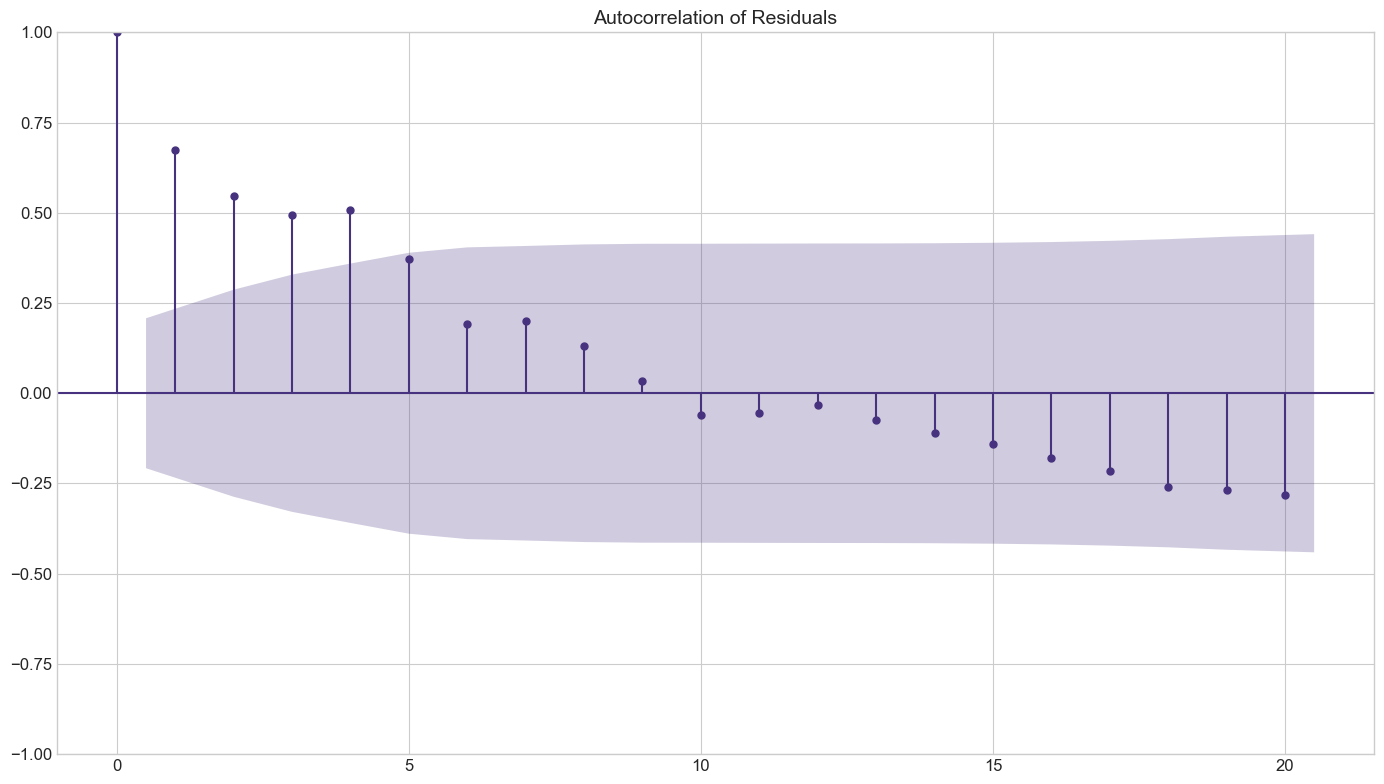

In [127]:
# Calculate residuals
residuals = y - in_sample_preds

# Plot residuals vs predicted values
plt.figure(figsize=(14, 7))
plt.scatter(in_sample_preds, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Ridge Regression: Residuals vs Predicted Values', fontsize=14)
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot residual distribution
plt.figure(figsize=(14, 7))
sns.histplot(residuals, kde=True)
plt.title('Ridge Regression: Distribution of Residuals', fontsize=14)
plt.xlabel('Residual Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Check for autocorrelation in residuals
plt.figure(figsize=(14, 7))
plot_acf(residuals, lags=20, alpha=0.05)
plt.title('Autocorrelation of Residuals', fontsize=14)
plt.tight_layout()
plt.show()

### 10. Summary and Conclusion

In [128]:

print("\n===== MODEL SUMMARY =====")
print(f"Best hyperparameters: alpha = {optimal_alpha}")
print("\nCross-Validation Performance:")
print(f"RMSE: {cv_rmse:.4f}")
print(f"MAE: {cv_mae:.4f}")
print(f"R²: {cv_r2:.4f}")

print("\nIn-Sample Performance:")
print(f"RMSE: {in_sample_rmse:.4f}")
print(f"MAE: {in_sample_mae:.4f}")
print(f"R²: {in_sample_r2:.4f}")

print("\nTop 5 most important features:")
for i in range(min(5, len(feature_importance))):
    feature = feature_importance.iloc[i]
    print(f"{i+1}. {feature['Feature']}: {feature['Coefficient']:.4f}")


===== MODEL SUMMARY =====
Best hyperparameters: alpha = 73.0

Cross-Validation Performance:
RMSE: 2.9470
MAE: 1.9113
R²: -1.7054

In-Sample Performance:
RMSE: 1.4762
MAE: 1.1374
R²: 0.5685

Top 5 most important features:
1. hot_market: 0.7788
2. recession_period: -0.3540
3. Interest_Rate_diff1: 0.2567
4. CPI: -0.2469
5. GDP_Growth: 0.2213
